In [ ]:
!pip install google-cloud-bigquery pandas-gbq scikit-learn matplotlib seaborn wordcloud --quiet
print("Done.")

Done.


In [ ]:
from google.colab import auth
auth.authenticate_user()
print("Authenticated.")

Authenticated.


In [ ]:
project_id   = 'bdao-group-yelp'
dataset_name = 'yelp_dataset'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from google.cloud import bigquery

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

bigquery_client = bigquery.Client(project=project_id)

def run_query(sql):
    """Run SQL on BigQuery and return a DataFrame."""
    return bigquery_client.query(sql).to_dataframe()

print(f'Connected: {project_id}')

Connected: bdao-group-yelp


In [ ]:
print('Loading yelp_restaurants...')

df_restaurants = run_query(f"""
    SELECT
        business_id, name, city, state, stars, review_count, is_open,
        RestaurantsTakeOut, RestaurantsDelivery, OutdoorSeating,
        RestaurantsReservations, WiFi, HasTV, GoodForKids,
        RestaurantsPriceRange2, Caters
    FROM `{project_id}.{dataset_name}.yelp_restaurants`
    WHERE is_open IS NOT NULL
""")

print(f'Loaded: {len(df_restaurants):,} rows, {df_restaurants.shape[1]} columns')
df_restaurants.head(3)

Loading yelp_restaurants...
Loaded: 52,286 rows, 16 columns


,business_id,name,city,state,stars,review_count,is_open,...,OutdoorSeating,RestaurantsReservations,WiFi,HasTV,GoodForKids,RestaurantsPriceRange2,Caters
0,Dy91wdWkwtI_qgjAIZ0Niw,Taqueria Los Primos,Wilmington,DE,4.00,23,1,...,False,False,no,True,True,1.00,False
1,Cdytv_YhJO0W0Ab8t2xLtg,Nippers Pub,Woodbury,NJ,3.50,29,1,...,True,False,no,True,False,1.00,None
2,P10BsKUeoeCeVoK4BS2u0w,Trust Me BBQ,Riverview,FL,4.00,29,0,...,True,False,no,False,True,1.00,True


In [ ]:
# 把 True/False 字符串转成 0/1 数字
def to_binary(series):
    return series.map(
        lambda x: 1 if str(x).strip() == 'True'
                  else (0 if str(x).strip() == 'False'
                  else np.nan)
    )

binary_cols = ['RestaurantsTakeOut', 'RestaurantsDelivery', 'OutdoorSeating',
               'RestaurantsReservations', 'HasTV', 'GoodForKids', 'Caters']

for col in binary_cols:
    df_restaurants[col] = to_binary(df_restaurants[col])

# WiFi 单独处理：free/paid = 1, no = 0
df_restaurants['WiFi'] = df_restaurants['WiFi'].map(
    lambda x: 1 if str(x).strip() in ('free','paid')
              else (0 if str(x).strip() == 'no'
              else np.nan)
)

# PriceRange 转数字
df_restaurants['RestaurantsPriceRange2'] = pd.to_numeric(
    df_restaurants['RestaurantsPriceRange2'], errors='coerce'
)

# 分成两组
df_high = df_restaurants[(df_restaurants['stars'] >= 4.0) & (df_restaurants['is_open'] == 1)].copy()
df_low  = df_restaurants[df_restaurants['stars'] < 3.5].copy()

print(f'高分餐厅 (stars≥4.0, open): {len(df_high):,}')
print(f'低分餐厅 (stars<3.5):        {len(df_low):,}')

高分餐厅 (stars≥4.0, open): 16,400
低分餐厅 (stars<3.5):        17,130


In [ ]:
# Q1 — 高分 vs 低分餐厅属性对比
attr_cols = ['RestaurantsTakeOut', 'RestaurantsDelivery', 'OutdoorSeating',
             'RestaurantsReservations', 'WiFi', 'HasTV', 'GoodForKids',
             'Caters', 'RestaurantsPriceRange2']

results = []
for col in attr_cols:
    rate_high = df_high[col].mean()
    rate_low  = df_low[col].mean()
    diff      = rate_high - rate_low
    results.append({
        'Attribute':   col,
        'High (≥4★)%': round(rate_high * 100, 1),
        'Low (<3.5★)%': round(rate_low  * 100, 1),
        'Difference':  round(diff * 100, 1)
    })

df_attr = pd.DataFrame(results).sort_values('Difference', ascending=False)
print(df_attr.to_string(index=False))

              Attribute  High (≥4★)%  Low (<3.5★)%  Difference
 RestaurantsPriceRange2       167.60        148.20       19.50
         OutdoorSeating        56.30         37.70       18.60
                 Caters        63.80         49.70       14.10
RestaurantsReservations        37.00         24.10       12.80
                   WiFi        57.70         52.00        5.60
     RestaurantsTakeOut        96.70         94.10        2.60
            GoodForKids        85.60         86.10       -0.50
    RestaurantsDelivery        66.70         67.80       -1.10
                  HasTV        74.40         83.10       -8.70


Price Range — 高分均值: 1.68 | 低分均值: 1.48


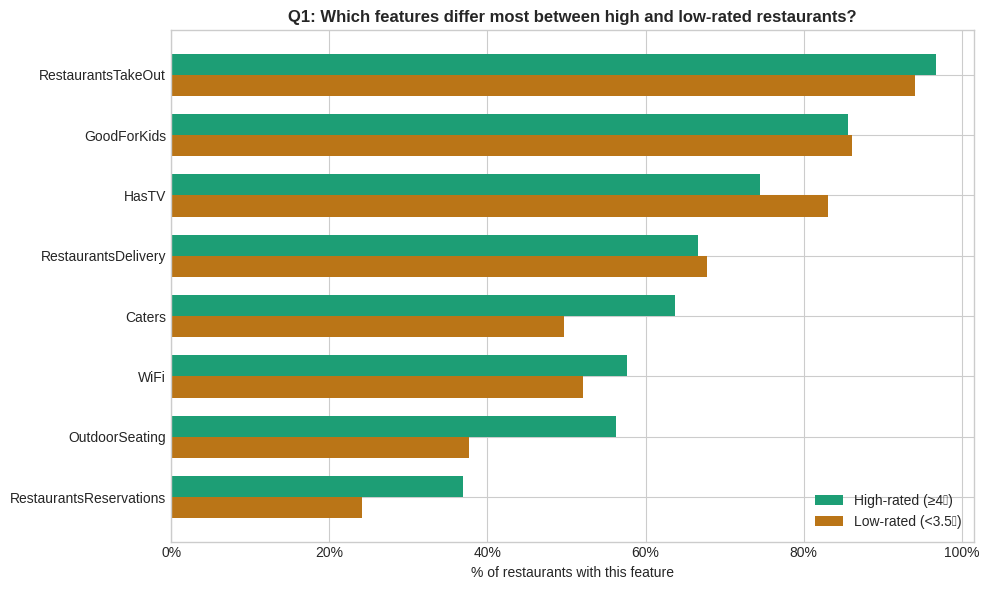


Price range insight: 高分餐厅平均价格区间 1.68 vs 低分 1.48


In [ ]:
# 修正 PriceRange — 单独计算均值，不用百分比
price_high = df_high['RestaurantsPriceRange2'].mean()
price_low  = df_low['RestaurantsPriceRange2'].mean()
print(f'Price Range — 高分均值: {price_high:.2f} | 低分均值: {price_low:.2f}')

# 只用 0/1 属性画图
plot_cols = ['OutdoorSeating','Caters','RestaurantsReservations','WiFi',
             'RestaurantsTakeOut','GoodForKids','RestaurantsDelivery','HasTV']

plot_data = []
for col in plot_cols:
    plot_data.append({
        'Attribute': col,
        'High (≥4★)': df_high[col].mean() * 100,
        'Low (<3.5★)': df_low[col].mean() * 100,
    })

df_plot = pd.DataFrame(plot_data).sort_values('High (≥4★)', ascending=True)

# 画图
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(df_plot))
width = 0.35

ax.barh([i + width/2 for i in x], df_plot['High (≥4★)'],  width, label='High-rated (≥4★)', color='#1D9E75')
ax.barh([i - width/2 for i in x], df_plot['Low (<3.5★)'], width, label='Low-rated (<3.5★)',  color='#BA7517')

ax.set_yticks(list(x))
ax.set_yticklabels(df_plot['Attribute'])
ax.set_xlabel('% of restaurants with this feature')
ax.set_title('Q1: Which features differ most between high and low-rated restaurants?',
             fontweight='bold', fontsize=12)
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

print(f'\nPrice range insight: 高分餐厅平均价格区间 {price_high:.2f} vs 低分 {price_low:.2f}')

Model AUC = 0.691


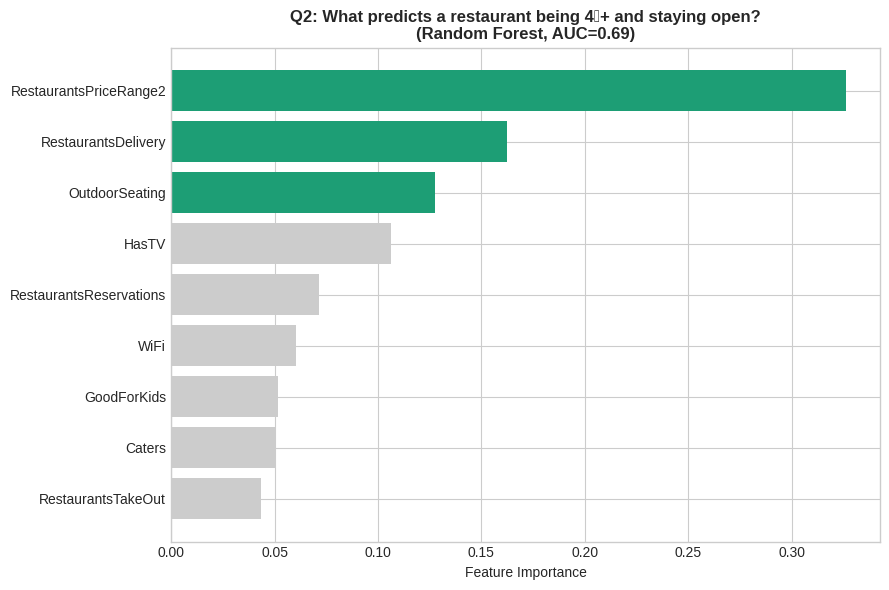

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 合并两组，建目标变量
df_model = pd.concat([
    df_high.assign(target=1),
    df_low.assign(target=0)
], ignore_index=True)

feature_cols = ['RestaurantsTakeOut','RestaurantsDelivery','OutdoorSeating',
                'RestaurantsReservations','WiFi','HasTV','GoodForKids',
                'Caters','RestaurantsPriceRange2']

X = df_model[feature_cols].fillna(df_model[feature_cols].median())
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f'Model AUC = {auc:.3f}')

# 特征重要性
importance_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

# 画图
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#1D9E75' if i >= len(importance_df)-3 else '#cccccc'
          for i in range(len(importance_df))]
ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
ax.set_xlabel('Feature Importance')
ax.set_title(f'Q2: What predicts a restaurant being 4★+ and staying open?\n(Random Forest, AUC={auc:.2f})',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter
import re

# 加载评论（抽样，控制速度）
print('Loading reviews...')
df_reviews = run_query(f"""
    SELECT r.text, b.stars as biz_stars
    FROM `{project_id}.{dataset_name}.yelp_reviews` r
    JOIN `{project_id}.{dataset_name}.yelp_restaurants` b
      ON r.business_id = b.business_id
    WHERE b.stars >= 4.0 AND b.is_open = 1 AND r.text IS NOT NULL
    LIMIT 20000
""")

df_reviews_low = run_query(f"""
    SELECT r.text, b.stars as biz_stars
    FROM `{project_id}.{dataset_name}.yelp_reviews` r
    JOIN `{project_id}.{dataset_name}.yelp_restaurants` b
      ON r.business_id = b.business_id
    WHERE b.stars < 3.5 AND r.text IS NOT NULL
    LIMIT 20000
""")

print(f'高分评论: {len(df_reviews):,} | 低分评论: {len(df_reviews_low):,}')

Loading reviews...
高分评论: 20,000 | 低分评论: 20,000


词频统计中...


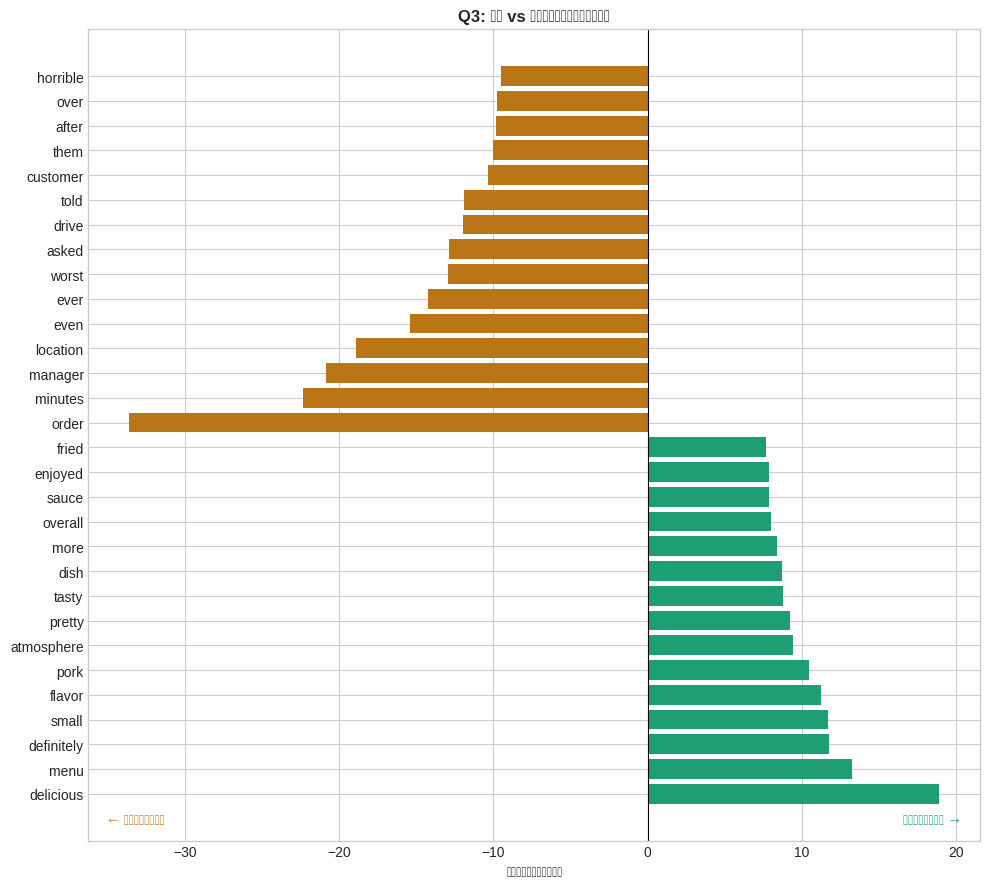


高分标志词 Top 5: ['delicious', 'menu', 'definitely', 'small', 'flavor']
低分标志词 Top 5: ['order', 'minutes', 'manager', 'location', 'even']


In [ ]:
STOPWORDS = set("""
i me my we our you your he she they it is was are were be been being
have has had do does did will would could should may might shall can
a an the and but or nor for so yet both either neither not no of in
on at to from with by about up out as if this that these those when
where what who which how then there here into just very really also
restaurant food place ordered came went got said made just like good
great nice little back came time get eat ate go going got day one
two three first well still never always every went back get also
i've i'm we're it's don't didn't wasn't can't couldn't
""".split())

def get_word_counts(texts):
    """文本列表 → 词频统计"""
    counter = Counter()
    for text in texts:
        text = str(text).lower()
        text = re.sub(r"[^a-z\s]", " ", text)
        words = [w for w in text.split() if len(w) > 3 and w not in STOPWORDS]
        counter.update(words)
    return counter

print('词频统计中...')
counter_high = get_word_counts(df_reviews['text'].tolist())
counter_low  = get_word_counts(df_reviews_low['text'].tolist())

n_high = sum(counter_high.values())
n_low  = sum(counter_low.values())

# 计算每个词在高分 vs 低分中的频率差
diff_scores = []
all_words = set(list(counter_high.keys()) + list(counter_low.keys()))

for word in all_words:
    freq_h = counter_high.get(word, 0) / n_high
    freq_l = counter_low.get(word, 0)  / n_low
    total  = counter_high.get(word, 0) + counter_low.get(word, 0)
    if total < 200:  # 过滤低频词，减少噪音
        continue
    diff_scores.append({'word': word, 'diff': freq_h - freq_l})

df_diff = pd.DataFrame(diff_scores).sort_values('diff', ascending=False)

# 取差距最大的各15个词画图
top_pos  = df_diff.head(15)
top_neg  = df_diff.tail(15).sort_values('diff')
combined = pd.concat([top_pos, top_neg])

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#1D9E75' if d > 0 else '#BA7517' for d in combined['diff']]
ax.barh(combined['word'], combined['diff'] * 10000, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('相对词频差异（每万词）')
ax.set_title('Q3: 高分 vs 低分餐厅评论中的标志性词汇',
             fontweight='bold', fontsize=12)
ax.annotate('← 低分餐厅更常出现', xy=(0.02, 0.02), xycoords='axes fraction',
            color='#BA7517', fontsize=10)
ax.annotate('高分餐厅更常出现 →', xy=(0.98, 0.02), xycoords='axes fraction',
            color='#1D9E75', fontsize=10, ha='right')
plt.tight_layout()
plt.show()

print('\n高分标志词 Top 5:', df_diff.head(5)['word'].tolist())
print('低分标志词 Top 5:', df_diff.tail(5).sort_values('diff')['word'].tolist())

success_attr_count  avg_stars  median_stars  restaurant_count
      0 attributes       3.27          3.50             12757
       1 attribute       3.58          3.50             12031
      2 attributes       3.77          4.00              7649
  All 3 attributes       3.78          4.00              2567


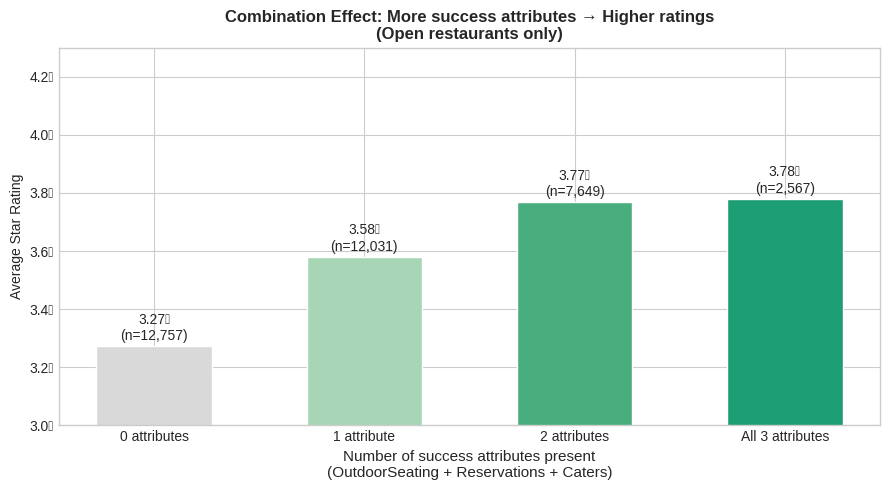

In [ ]:
# ── 组合属性分析 ──────────────────────────────────────────
# 逻辑：把 Q1 中差距最大的三个属性加起来，
# 看拥有 0 / 1 / 2 / 3 个属性的餐厅，评分分布如何变化

# 只用仍在营业的餐厅
df_open = df_restaurants[df_restaurants['is_open'] == 1].copy()

# 三个核心属性（Q1 差距最大）
df_open['has_outdoor']      = (df_open['OutdoorSeating'] == 1).astype(int)
df_open['has_reservations'] = (df_open['RestaurantsReservations'] == 1).astype(int)
df_open['has_caters']       = (df_open['Caters'] == 1).astype(int)

# 计算每家餐厅拥有几个成功属性（0-3）
df_open['success_attr_count'] = (
    df_open['has_outdoor'] +
    df_open['has_reservations'] +
    df_open['has_caters']
)

# 按属性数量分组，计算平均评分和餐厅数量
combo_summary = (
    df_open.groupby('success_attr_count')
    .agg(
        avg_stars    = ('stars', 'mean'),
        median_stars = ('stars', 'median'),
        restaurant_count = ('business_id', 'count')
    )
    .round(3)
    .reset_index()
)

combo_summary['success_attr_count'] = combo_summary['success_attr_count'].map({
    0: '0 attributes',
    1: '1 attribute',
    2: '2 attributes',
    3: 'All 3 attributes'
})

print(combo_summary.to_string(index=False))

# 画图
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#d9d9d9', '#a8d5b5', '#4aad7e', '#1D9E75']
bars = ax.bar(combo_summary['success_attr_count'],
              combo_summary['avg_stars'],
              color=colors, edgecolor='white', width=0.55)

# 在每个柱子上标注数值和餐厅数量
for bar, avg, count in zip(bars, combo_summary['avg_stars'], combo_summary['restaurant_count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{avg:.2f}★\n(n={count:,})', ha='center', va='bottom', fontsize=10)

ax.set_ylim(3.0, 4.3)
ax.set_xlabel('Number of success attributes present\n(OutdoorSeating + Reservations + Caters)',
              fontsize=11)
ax.set_ylabel('Average Star Rating')
ax.set_title('Combination Effect: More success attributes → Higher ratings\n(Open restaurants only)',
             fontweight='bold', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}★'))
plt.tight_layout()
plt.show()

Top 8 cities: ['Philadelphia', 'Tampa', 'Indianapolis', 'Nashville', 'Tucson', 'Edmonton', 'New Orleans', 'Saint Louis']


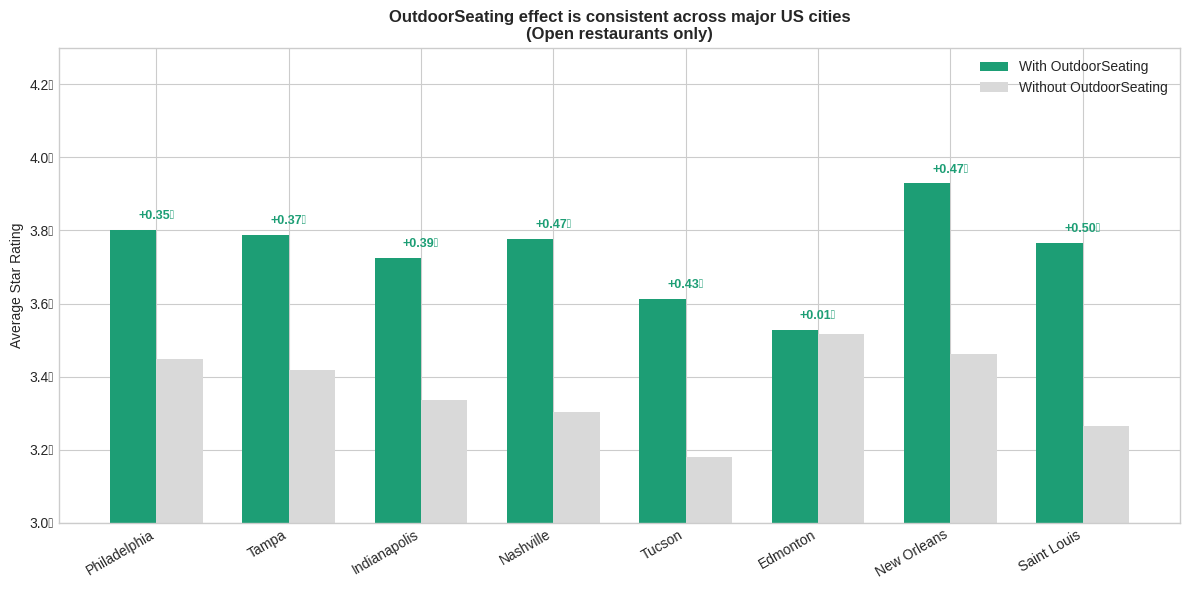

In [ ]:
# ── 城市对比分析 ──────────────────────────────────────────
# 逻辑：在数据量最大的城市里，分别看 OutdoorSeating
# 对评分的影响是否一致，证明发现具有普遍性

# 找出餐厅数量最多的前8个城市
top_cities = (
    df_open.groupby('city')['business_id']
    .count()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)

print('Top 8 cities:', top_cities)

# 在每个城市里，比较有/无 OutdoorSeating 的平均评分
city_results = []

for city in top_cities:
    df_city = df_open[df_open['city'] == city]

    for has_attr, label in [(1, 'With OutdoorSeating'), (0, 'Without OutdoorSeating')]:
        subset = df_city[df_city['OutdoorSeating'] == has_attr]
        if len(subset) < 30:
            continue
        city_results.append({
            'city':    city,
            'group':   label,
            'avg_stars': subset['stars'].mean(),
            'n':       len(subset)
        })

df_city_plot = pd.DataFrame(city_results)

# 画图
fig, ax = plt.subplots(figsize=(12, 6))

cities    = df_city_plot['city'].unique()
x         = np.arange(len(cities))
width     = 0.35

with_vals    = df_city_plot[df_city_plot['group'] == 'With OutdoorSeating'].set_index('city')
without_vals = df_city_plot[df_city_plot['group'] == 'Without OutdoorSeating'].set_index('city')

bars1 = ax.bar(x - width/2,
               [with_vals.loc[c, 'avg_stars'] for c in cities],
               width, label='With OutdoorSeating',    color='#1D9E75')
bars2 = ax.bar(x + width/2,
               [without_vals.loc[c, 'avg_stars'] for c in cities],
               width, label='Without OutdoorSeating', color='#d9d9d9')

# 标注差值
for i, city in enumerate(cities):
    diff = with_vals.loc[city, 'avg_stars'] - without_vals.loc[city, 'avg_stars']
    ax.text(i, max(with_vals.loc[city, 'avg_stars'],
                   without_vals.loc[city, 'avg_stars']) + 0.03,
            f'+{diff:.2f}★', ha='center', fontsize=9, color='#1D9E75', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(cities, rotation=30, ha='right')
ax.set_ylim(3.0, 4.3)
ax.set_ylabel('Average Star Rating')
ax.set_title('OutdoorSeating effect is consistent across major US cities\n(Open restaurants only)',
             fontweight='bold', fontsize=12)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}★'))
plt.tight_layout()
plt.show()

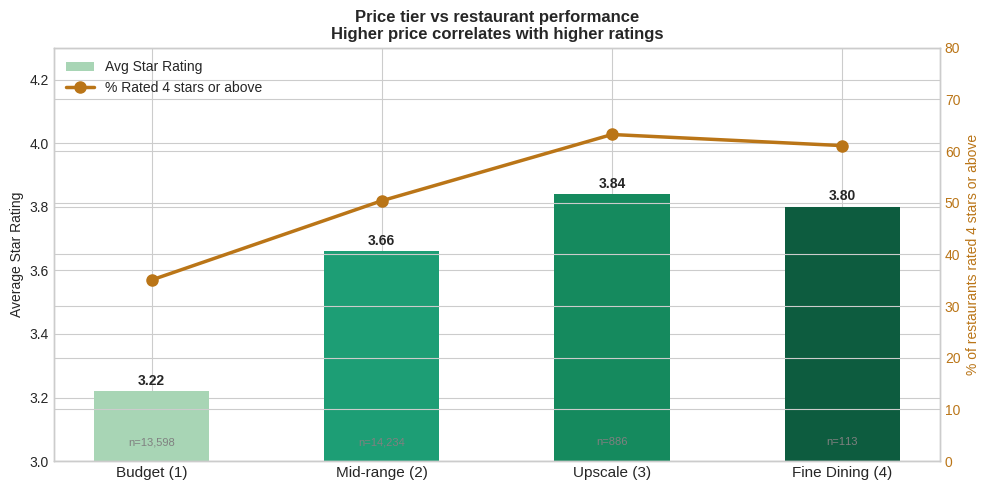

In [ ]:
price_summary['price_label'] = price_summary['price_tier'].map({
    1: 'Budget (1)',
    2: 'Mid-range (2)',
    3: 'Upscale (3)',
    4: 'Fine Dining (4)'
})

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

x = np.arange(len(price_summary))
colors = ['#a8d5b5', '#1D9E75', '#158a5e', '#0d5c3f']

bars = ax1.bar(x, price_summary['avg_stars'],
               color=colors, width=0.5, label='Avg Star Rating')

ax2.plot(x, price_summary['pct_high_rated'],
         color='#BA7517', marker='o', linewidth=2.5,
         markersize=8, label='% Rated 4 stars or above')

for i, (avg, pct, count) in enumerate(zip(
        price_summary['avg_stars'],
        price_summary['pct_high_rated'],
        price_summary['restaurant_count'])):
    ax1.text(i, avg + 0.02, f'{avg:.2f}', ha='center', fontsize=10, fontweight='bold')
    ax1.text(i, 3.05, f'n={count:,}', ha='center', fontsize=8, color='grey')

ax1.set_xticks(x)
ax1.set_xticklabels(price_summary['price_label'], fontsize=11)
ax1.set_ylim(3.0, 4.3)
ax1.set_ylabel('Average Star Rating')

ax2.set_ylim(0, 80)
ax2.set_ylabel('% of restaurants rated 4 stars or above', color='#BA7517')
ax2.tick_params(axis='y', colors='#BA7517')

ax1.set_title('Price tier vs restaurant performance\nHigher price correlates with higher ratings',
              fontweight='bold', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# 缺失值分析 — NULL 餐厅 vs 有值餐厅的评分分布
missing_analysis = []

for col in ['OutdoorSeating','RestaurantsReservations','RestaurantsPriceRange2',
            'WiFi','HasTV','GoodForKids','Caters','RestaurantsTakeOut','RestaurantsDelivery']:

    has_value = df_restaurants[df_restaurants[col].notna()]
    is_null   = df_restaurants[df_restaurants[col].isna()]

    missing_analysis.append({
        'Feature':        col,
        'Null count':     df_restaurants[col].isna().sum(),
        'Null %':         f"{df_restaurants[col].isna().mean()*100:.1f}%",
        'Avg stars (has value)': round(has_value['stars'].mean(), 2),
        'Avg stars (NULL)':      round(is_null['stars'].mean(), 2),
        'Difference':     round(has_value['stars'].mean() - is_null['stars'].mean(), 2)
    })

df_missing = pd.DataFrame(missing_analysis).sort_values('Null count', ascending=False)
print(df_missing.to_string(index=False))

                Feature  Null count Null %  Avg stars (has value)  Avg stars (NULL)  Difference
                 Caters       17760  34.0%                   3.56              3.42        0.14
                   WiFi       14573  27.9%                   3.56              3.39        0.17
            GoodForKids       11331  21.7%                   3.46              3.72       -0.27
         OutdoorSeating       10403  19.9%                   3.51              3.52       -0.00
                  HasTV       10387  19.9%                   3.53              3.46        0.07
RestaurantsReservations        9429  18.0%                   3.49              3.64       -0.15
 RestaurantsPriceRange2        7789  14.9%                   3.47              3.80       -0.34
    RestaurantsDelivery        7224  13.8%                   3.49              3.70       -0.21
     RestaurantsTakeOut        4654   8.9%                   3.50              3.65       -0.15


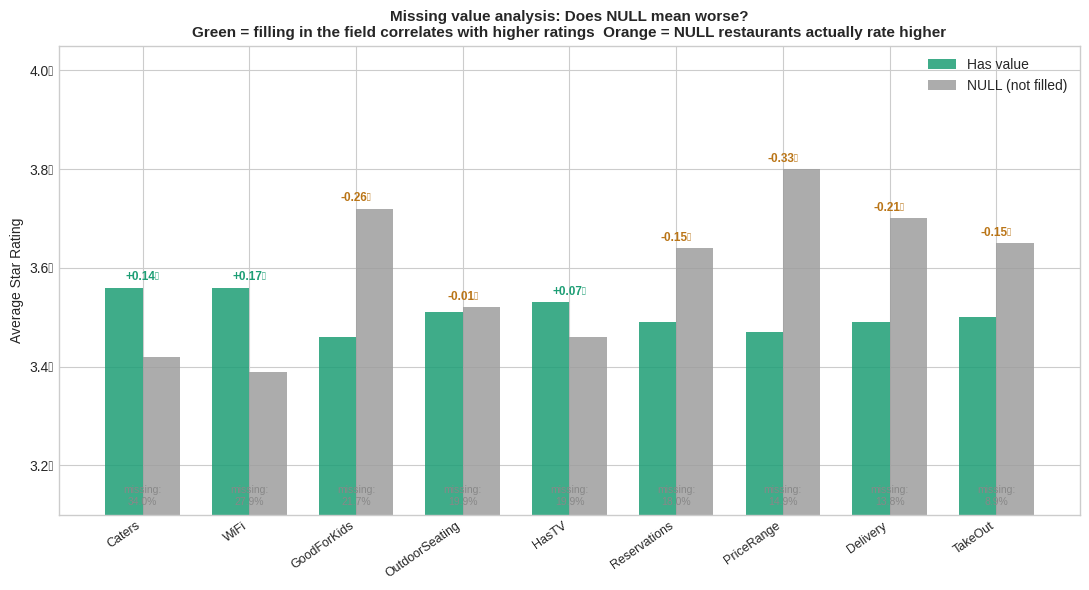

In [ ]:
# 可视化缺失值的影响
fig, ax = plt.subplots(figsize=(11, 6))

features = df_missing['Feature'].tolist()
x = np.arange(len(features))
width = 0.35

bars1 = ax.bar(x - width/2, df_missing['Avg stars (has value)'],
               width, label='Has value', color='#1D9E75', alpha=0.85)
bars2 = ax.bar(x + width/2, df_missing['Avg stars (NULL)'],
               width, label='NULL (not filled)', color='#9E9E9E', alpha=0.85)

# 标注差值
for i, (hv, nv) in enumerate(zip(df_missing['Avg stars (has value)'],
                                  df_missing['Avg stars (NULL)'])):
    diff = hv - nv
    color = '#1D9E75' if diff > 0 else '#BA7517'
    sign  = '+' if diff > 0 else ''
    higher = max(hv, nv)
    ax.text(i, higher + 0.015, f'{sign}{diff:.2f}★',
            ha='center', fontsize=8.5, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f.replace('Restaurants','').replace('Range2','Range')
                    for f in features], rotation=35, ha='right', fontsize=9)
ax.set_ylim(3.1, 4.05)
ax.set_ylabel('Average Star Rating')
ax.set_title('Missing value analysis: Does NULL mean worse?\n'
             'Green = filling in the field correlates with higher ratings  '
             'Orange = NULL restaurants actually rate higher',
             fontweight='bold', fontsize=11)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}★'))

# 标注缺失率
for i, (feat, null_pct) in enumerate(zip(df_missing['Feature'],
                                          df_missing['Null %'])):
    ax.text(i, 3.12, f'missing:\n{null_pct}',
            ha='center', fontsize=7.5, color='#888888')

plt.tight_layout()
plt.show()

Loading review length data...
Loaded: 30,000 reviews
biz_stars_band  avg_length  median_length  review_count
        1-2.5★      535.00         386.00          2041
        2.5-3★      567.00         413.00          2775
        3-3.5★      561.00         408.00          6834
        3.5-4★      550.00         391.00         11556
        4-4.5★      515.00         353.00          6500
        4.5-5★      458.00         330.00           294


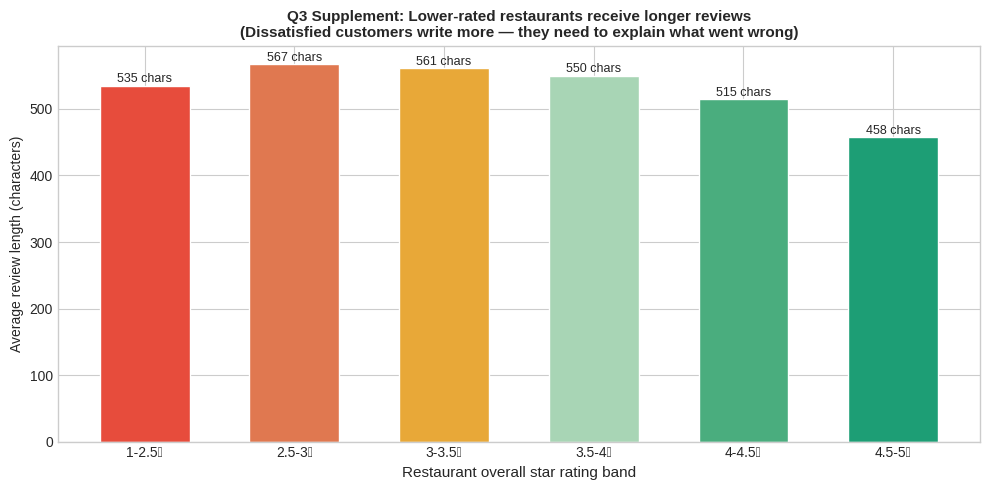

In [ ]:
# ── 评论长度 vs 评分分析 ──────────────────────────────────────
# 逻辑：不满意的顾客写得更详细（需要解释哪里出了问题）
# 满意的顾客往往只写简短正面评价

# 从 BigQuery 拉取评论长度 + 餐厅评分
print('Loading review length data...')
df_rev_length = run_query(f"""
    SELECT
        r.business_id,
        r.stars AS review_stars,
        LENGTH(r.text) AS review_length,
        b.stars AS biz_stars
    FROM `{project_id}.{dataset_name}.yelp_reviews` r
    JOIN `{project_id}.{dataset_name}.yelp_restaurants` b
      ON r.business_id = b.business_id
    WHERE r.text IS NOT NULL
      AND b.stars IS NOT NULL
    ORDER BY RAND()
    LIMIT 30000
""")

print(f'Loaded: {len(df_rev_length):,} reviews')

# 按餐厅评分分组，计算平均评论长度
df_rev_length['biz_stars_band'] = pd.cut(
    df_rev_length['biz_stars'],
    bins=[0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    labels=['1-2.5★', '2.5-3★', '3-3.5★', '3.5-4★', '4-4.5★', '4.5-5★']
)

length_by_stars = (
    df_rev_length.groupby('biz_stars_band', observed=True)
    .agg(
        avg_length = ('review_length', 'mean'),
        median_length = ('review_length', 'median'),
        review_count = ('review_length', 'count')
    )
    .round(0)
    .reset_index()
)

print(length_by_stars.to_string(index=False))

# 画图
fig, ax1 = plt.subplots(figsize=(10, 5))

colors = ['#e74c3c','#e07850','#e8a838','#a8d5b5','#4aad7e','#1D9E75']
bars = ax1.bar(length_by_stars['biz_stars_band'],
               length_by_stars['avg_length'],
               color=colors, width=0.6, edgecolor='white')

# 标注数值
for bar, val in zip(bars, length_by_stars['avg_length']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.0f} chars', ha='center', fontsize=9)

ax1.set_xlabel('Restaurant overall star rating band', fontsize=11)
ax1.set_ylabel('Average review length (characters)')
ax1.set_title('Q3 Supplement: Lower-rated restaurants receive longer reviews\n'
              '(Dissatisfied customers write more — they need to explain what went wrong)',
              fontweight='bold', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

plt.tight_layout()
plt.show()

Overall delivery effect:
              mean  count
No Delivery   3.74   8222
Has Delivery  3.39  22178

Delivery effect by price tier:
has_delivery     No Delivery  Has Delivery  Delivery effect
price_label                                                
Budget (1)              3.71          3.02            -0.69
Fine Dining (4)         3.83          3.70            -0.13
Mid-range (2)           3.69          3.63            -0.06
Upscale (3)             3.83          3.80            -0.03


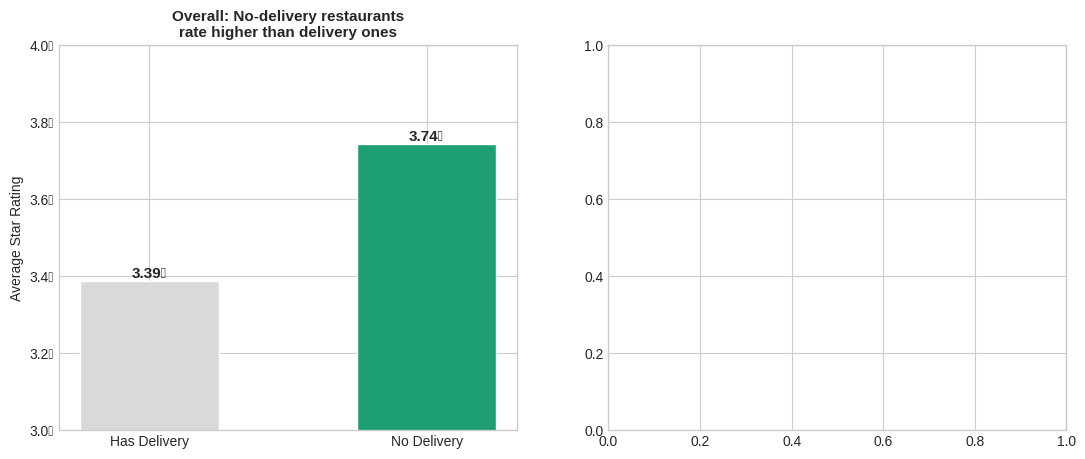

In [ ]:
# ── Delivery 反向分析 ─────────────────────────────────────────
# 逻辑：外卖是大众餐厅的特征，不是成功标志
# 按价格区间分组，看 Delivery 的效果是否一致

df_del = df_open[df_open['RestaurantsDelivery'].notna()].copy()
df_del['has_delivery'] = df_del['RestaurantsDelivery'].astype(int)
df_del['price_label'] = df_del['RestaurantsPriceRange2'].map(
    {1.0: 'Budget (1)', 2.0: 'Mid-range (2)',
     3.0: 'Upscale (3)', 4.0: 'Fine Dining (4)'}
)

# 整体对比
overall = df_del.groupby('has_delivery')['stars'].agg(['mean','count']).round(3)
overall.index = ['No Delivery', 'Has Delivery']
print("Overall delivery effect:")
print(overall)
print()

# 按价格区间分组
price_delivery = (
    df_del[df_del['price_label'].notna()]
    .groupby(['price_label', 'has_delivery'])['stars']
    .mean()
    .round(2)
    .unstack()
    .rename(columns={0: 'No Delivery', 1: 'Has Delivery'})
)
price_delivery['Delivery effect'] = (
    price_delivery['Has Delivery'] - price_delivery['No Delivery']
).round(2)
print("Delivery effect by price tier:")
print(price_delivery)

# 画图
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左图：整体对比
colors_overall = ['#1D9E75', '#d9d9d9']
bars = axes[0].bar(['Has Delivery', 'No Delivery'],
                   [df_del[df_del['has_delivery']==1]['stars'].mean(),
                    df_del[df_del['has_delivery']==0]['stars'].mean()],
                   color=['#d9d9d9','#1D9E75'], width=0.5, edgecolor='white')

for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}★', ha='center', fontsize=11, fontweight='bold')

axes[0].set_ylim(3.0, 4.0)
axes[0].set_ylabel('Average Star Rating')
axes[0].set_title('Overall: No-delivery restaurants\nrate higher than delivery ones',
                  fontweight='bold', fontsize=11)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}★'))

# 右图：按价格区间
x = np.arange(len(price_delivery))
w = 0.35

Rows after filter: 26266
Price label counts:
price_label
Mid-range (2)      12745
Budget (1)         12710
Upscale (3)          726
Fine Dining (4)       85
Name: count, dtype: int64

Delivery effect by price tier:
has_delivery     No Delivery  Has Delivery
price_label                               
Budget (1)              3.71          3.02
Fine Dining (4)         3.83          3.70
Mid-range (2)           3.69          3.63
Upscale (3)             3.83          3.80


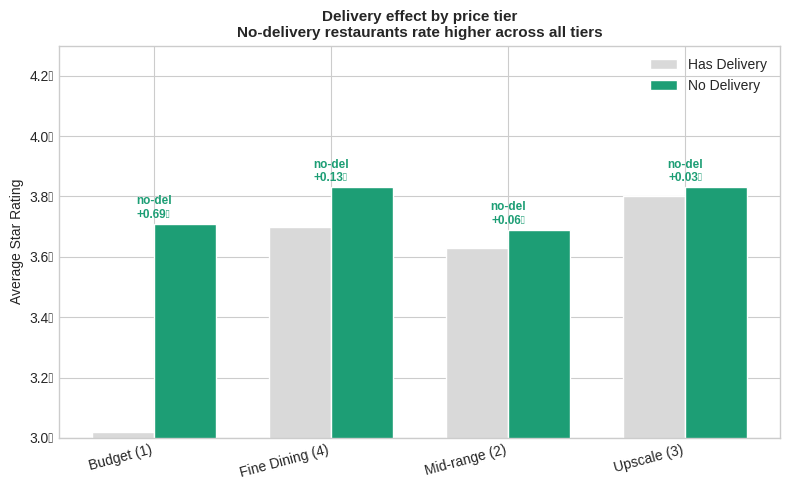

In [ ]:
# 修正版 — 右图单独跑
df_del2 = df_open[df_open['RestaurantsDelivery'].notna() &
                  df_open['RestaurantsPriceRange2'].notna()].copy()
df_del2['has_delivery'] = df_del2['RestaurantsDelivery'].astype(int)

# 用 astype(int) 再 map
df_del2['price_label'] = df_del2['RestaurantsPriceRange2'].astype(int).map(
    {1: 'Budget (1)', 2: 'Mid-range (2)',
     3: 'Upscale (3)', 4: 'Fine Dining (4)'}
)

print("Rows after filter:", len(df_del2))
print("Price label counts:")
print(df_del2['price_label'].value_counts())

price_delivery = (
    df_del2.groupby(['price_label', 'has_delivery'])['stars']
    .mean().round(2).unstack()
    .rename(columns={0: 'No Delivery', 1: 'Has Delivery'})
)
print("\nDelivery effect by price tier:")
print(price_delivery)

# 右图
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(price_delivery))
w = 0.35

ax.bar(x - w/2, price_delivery['Has Delivery'],
       w, label='Has Delivery', color='#d9d9d9', edgecolor='white')
ax.bar(x + w/2, price_delivery['No Delivery'],
       w, label='No Delivery', color='#1D9E75', edgecolor='white')

for i, (hd, nd) in enumerate(zip(price_delivery['Has Delivery'],
                                  price_delivery['No Delivery'])):
    diff = nd - hd
    ax.text(i, max(hd, nd) + 0.02,
            f'no-del\n+{diff:.2f}★', ha='center',
            fontsize=8.5, color='#1D9E75', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(price_delivery.index, rotation=15, ha='right')
ax.set_ylim(3.0, 4.3)
ax.set_ylabel('Average Star Rating')
ax.set_title('Delivery effect by price tier\n'
             'No-delivery restaurants rate higher across all tiers',
             fontweight='bold', fontsize=11)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}★'))
plt.tight_layout()
plt.show()

In [ ]:
# 把图保存成文件，方便插进PPT
fig.savefig('delivery_analysis.png', dpi=150, bbox_inches='tight')

Keyword  Reviews with it  % of all reviews  Avg ★ (with)  Avg ★ (without)  Rating gap
manager             2462              6.20          2.93             3.42       -0.49
   rude             1689              4.20          3.02             3.41       -0.39
minutes             4403             11.00          3.11             3.42       -0.31
  wrong             1825              4.60          3.13             3.40       -0.27
  order             7830             19.60          3.20             3.44       -0.24
   cold             2236              5.60          3.18             3.40       -0.22
   slow             1549              3.90          3.25             3.40       -0.14
   wait             4219             10.50          3.40             3.39        0.01


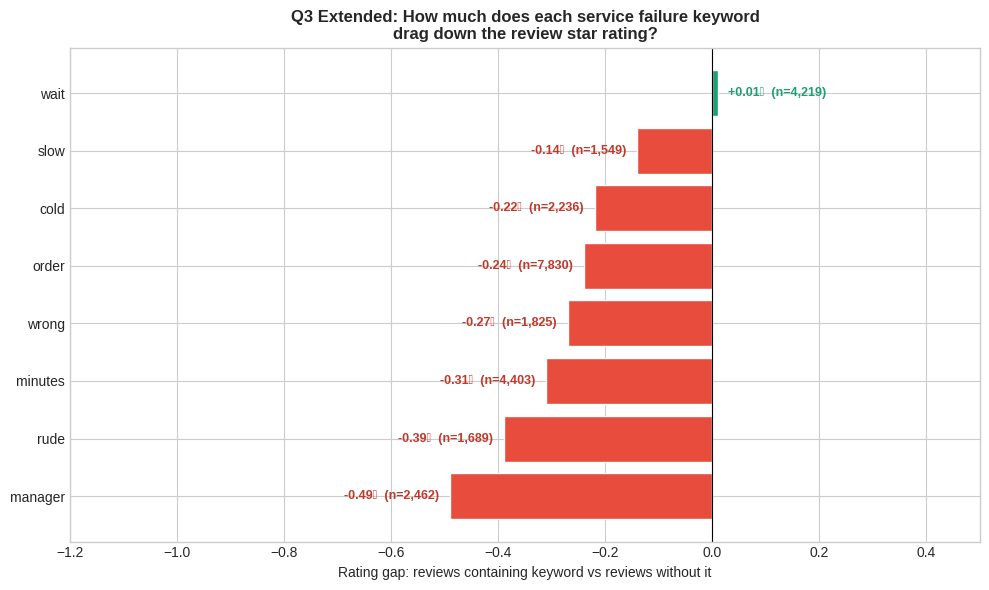

In [ ]:
# ── 服务失误关键词的评分影响量化 ─────────────────────────────
# 逻辑：低分评论里 'order', 'minutes', 'manager' 出现最多
# 现在量化：包含这些词的评论，平均评分比不包含的低多少？

import re

# 合并高分和低分评论
df_all_reviews = pd.concat([
    df_reviews.assign(group='high'),
    df_reviews_low.assign(group='low')
], ignore_index=True)

# 定义要分析的关键词
keywords = {
    'order':   r'\border\b',
    'minutes': r'\bminutes\b',
    'manager': r'\bmanager\b',
    'wait':    r'\bwait\b',
    'slow':    r'\bslow\b',
    'cold':    r'\bcold\b',
    'wrong':   r'\bwrong\b',
    'rude':    r'\brude\b',
}

results = []
for word, pattern in keywords.items():
    has_word = df_all_reviews['text'].str.lower().str.contains(pattern, regex=True)

    avg_with    = df_all_reviews[has_word]['biz_stars'].mean()
    avg_without = df_all_reviews[~has_word]['biz_stars'].mean()
    count_with  = has_word.sum()
    pct_with    = has_word.mean() * 100

    results.append({
        'Keyword':         word,
        'Reviews with it': count_with,
        '% of all reviews': round(pct_with, 1),
        'Avg ★ (with)':    round(avg_with, 2),
        'Avg ★ (without)': round(avg_without, 2),
        'Rating gap':      round(avg_with - avg_without, 2)
    })

df_kw = pd.DataFrame(results).sort_values('Rating gap')
print(df_kw.to_string(index=False))

# 画图
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if g < 0 else '#1D9E75' for g in df_kw['Rating gap']]
bars = ax.barh(df_kw['Keyword'], df_kw['Rating gap'], color=colors, edgecolor='white')

# 标注数值和样本量
for bar, gap, count in zip(bars, df_kw['Rating gap'], df_kw['Reviews with it']):
    ax.text(bar.get_width() - 0.02 if gap < 0 else bar.get_width() + 0.02,
            bar.get_y() + bar.get_height()/2,
            f'{gap:+.2f}★  (n={count:,})',
            va='center', ha='right' if gap < 0 else 'left',
            fontsize=9, fontweight='bold',
            color='#c0392b' if gap < 0 else '#1D9E75')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Rating gap: reviews containing keyword vs reviews without it')
ax.set_title('Q3 Extended: How much does each service failure keyword\n'
             'drag down the review star rating?',
             fontweight='bold', fontsize=12)
ax.set_xlim(-1.2, 0.5)
plt.tight_layout()
plt.show()